
Training MLP with MAE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0345 - val_loss: 0.0384
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0251 - val_loss: 0.0369
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0222 - val_loss: 0.0360
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0221 - val_loss: 0.0347
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0218 - val_loss: 0.0349
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0191 - val_loss: 0.0356
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0175 - val_loss: 0.0347
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0191 - val_loss: 0.0349
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0201 - val_loss: 0.0346
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


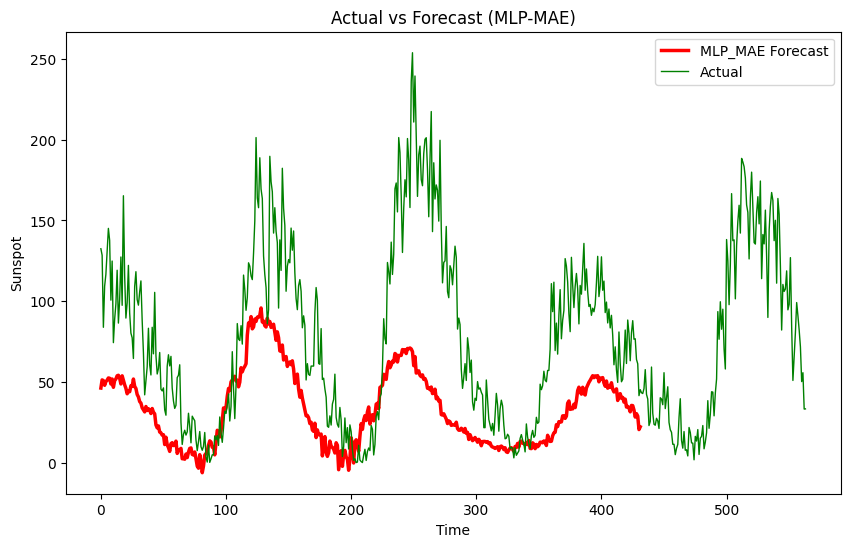


Evaluation Metrics
MSE   : 3767.970787084542
RMSE  : 61.38379906037538
NRMSE: 0.24204968083744233
MAE   : 47.46788874505556
SMAPE : 82.60418311527967
MASE  : 3.205430481648092


In [1]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MAE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MAE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanAbsoluteError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MAE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MAE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (ALL PATHS FILLED)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\x_train_sunspot_full_5.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\y_train_sunspot_full_5.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_sunspot_final_5.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_daily_sunspot_loss_history_5.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_5.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_5.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled_5.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled_5.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with MSE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0063 - val_loss: 0.0104
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0060 - val_loss: 0.0104
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0043 - val_loss: 0.0099
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0054 - val_loss: 0.0102
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0038 - val_loss: 0.0101
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0044 - val_loss: 0.0101
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027 - val_loss: 0.0103
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0033 - val_loss: 0.0112
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


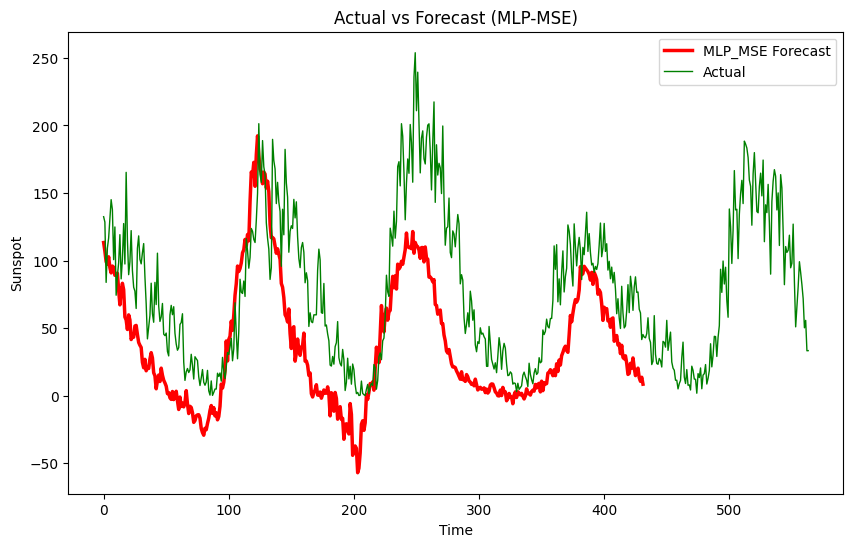


Evaluation Metrics
MSE   : 2625.170685633471
RMSE  : 51.236419523942835
NRMSE: 0.20203635458967995
MAE   : 42.784473972995244
SMAPE : 104.82491536607097
MASE  : 2.8891669850937642


In [2]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MSE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MSE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanSquaredError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MSE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MSE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (MSE NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\x_train_sunspot_full_5.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\y_train_sunspot_full_5.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_final_5.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_loss_history_5.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_5.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_5.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled_5.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled_5.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Huber loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 0.0012 - val_loss: 0.0021
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - loss: 0.0012 - val_loss: 0.0021
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 0.0014 - val_loss: 0.0021
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - loss: 9.9074e-04 - val_loss: 0.0021
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - loss: 0.0011 - val_loss: 0.0020
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - loss: 7.6923e-04 - val_loss: 0.0021
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - loss: 7.9166e-04 - val_loss: 0.0021
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


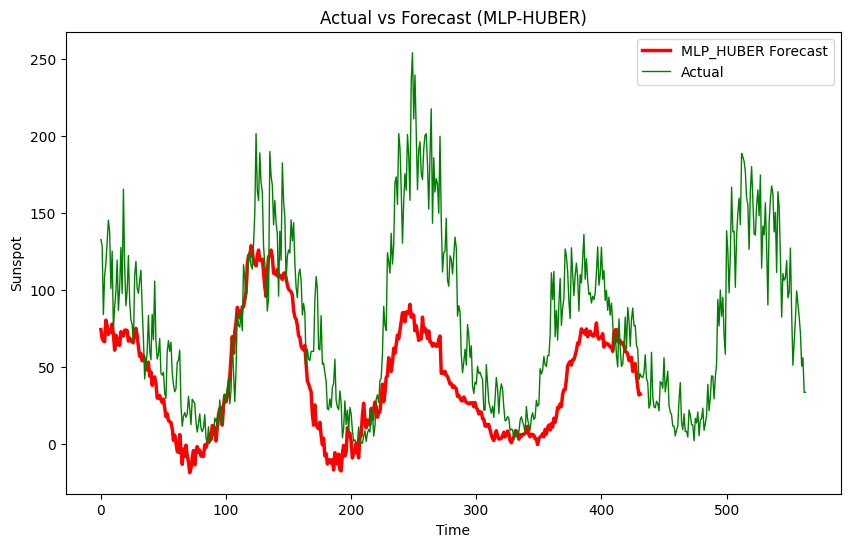


Evaluation Metrics
MSE   : 2499.288432714122
RMSE  : 49.99288382074115
NRMSE: 0.1971328226369919
MAE   : 38.86957596980756
SMAPE : 81.94953333971777
MASE  : 2.6248001947492456


In [1]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. HUBER LOSS (CUSTOM DEFINITION)
# =========================================================
def huber_loss(delta=1.0):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, delta)
        linear = abs_error - quadratic
        return tf.reduce_mean(0.5 * tf.square(quadratic) + delta * linear)
    return loss


# =========================================================
# 4. TRAIN MODEL (HUBER LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Huber loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=huber_loss(delta=cfg['huber_delta'])
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'loss': huber_loss(cfg['huber_delta'])}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_HUBER Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-HUBER)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HUBER NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'huber_delta': 0.103,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\x_train_sunspot_full_5.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\y_train_sunspot_full_5.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_final_5.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_loss_history_5.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_5.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_5.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled_5.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled_5.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Log-Cosh loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - val_loss: 0.0048
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0027 - val_loss: 0.0046
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0028 - val_loss: 0.0047
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - val_loss: 0.0047
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - loss: 0.0013 - val_loss: 0.0047
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - loss: 0.0019 - val_loss: 0.0049
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - loss: 0.0014 - val_loss: 0.0046
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


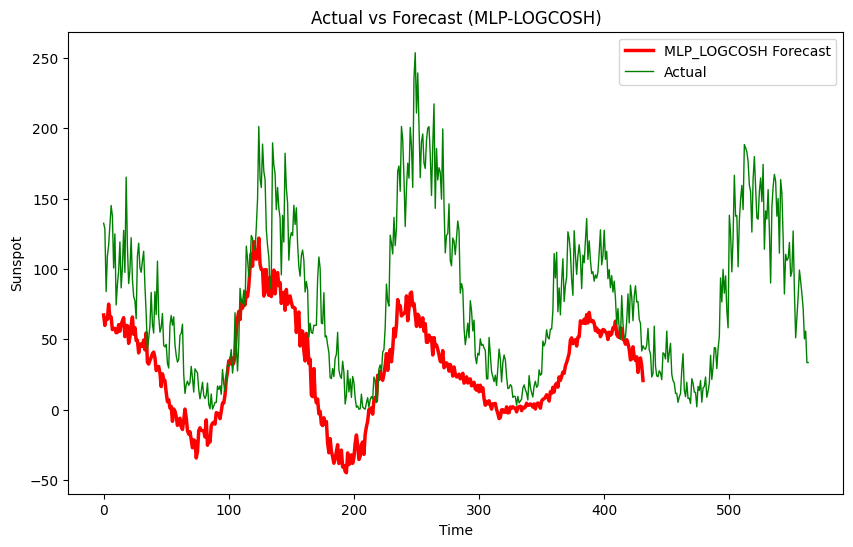


Evaluation Metrics
MSE   : 3554.5321823159297
RMSE  : 59.61989753694591
NRMSE: 0.2350942331898498
MAE   : 50.20354438771599
SMAPE : 109.33452000455969
MASE  : 3.390164924575886


In [3]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. LOG-COSH LOSS (CUSTOM DEFINITION)
# =========================================================
def logcosh_loss(y_true, y_pred):
    return tf.reduce_mean(tf.math.log(tf.cosh(y_pred - y_true)))


# =========================================================
# 4. TRAIN MODEL (LOG-COSH LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Log-Cosh loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=logcosh_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'logcosh_loss': logcosh_loss}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_LOGCOSH Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-LOGCOSH)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (LOG-COSH NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\x_train_sunspot_full_5.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\y_train_sunspot_full_5.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_final_5.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_loss_history_5.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_5.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_5.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled_5.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled_5.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP using RoBoSS loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.5008e-04 - val_loss: 3.1336e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5838e-04 - val_loss: 3.6802e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5786e-04 - val_loss: 3.7043e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7988e-04 - val_loss: 3.4523e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0456e-04 - val_loss: 3.3398e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.7089e-05 - val_loss: 3.3693e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


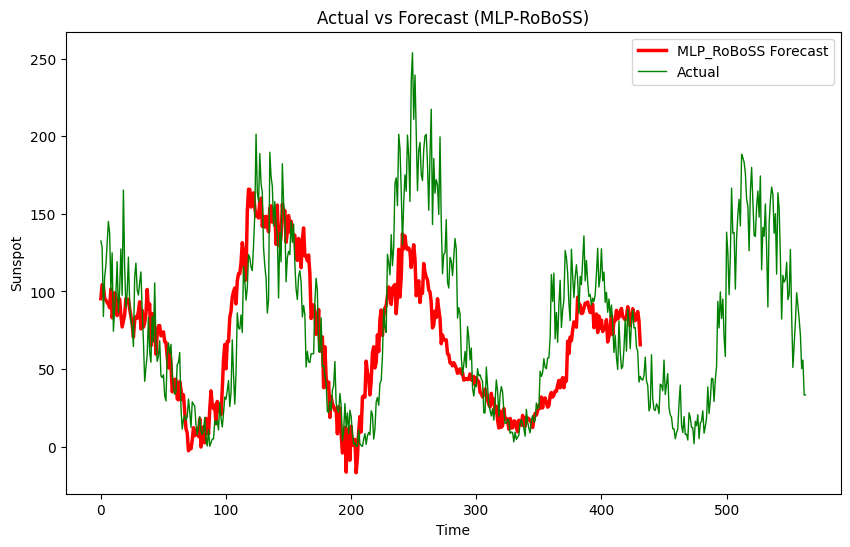


Evaluation Metrics
MSE   : 1581.7693212887086
RMSE  : 39.771463655348526
NRMSE: 0.15682753807314087
MAE   : 29.961157207108204
SMAPE : 48.167382933010835
MASE  : 2.0232289473190184


In [4]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. ROBOSS LOSS
# =========================================================
def roboss_nn_loss(y_true, y_pred, a, epsilon, lam):
    u = tf.abs(y_true - y_pred)
    val = a * tf.sqrt(tf.square(u) + epsilon) - a * tf.sqrt(epsilon)
    loss_val = lam * (1 - (val + 1) * tf.exp(-val))
    return tf.reduce_mean(loss_val)


# =========================================================
# 2. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 3. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 4. TRAIN MODEL (ROBOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP using RoBoSS loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=dynamic_roboss_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'dynamic_roboss_loss': dynamic_roboss_loss,
            'roboss_nn_loss': roboss_nn_loss
        }
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)

    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_RoBoSS Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-RoBoSS)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'a': 1.099,
    'epsilon': 0.038,
    'lam': 0.183,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\x_train_sunspot_full_5.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\y_train_sunspot_full_5.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_sunspot_final_5.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_daily_sunspot_loss_history_5.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_5.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_5.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled_5.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled_5.csv"
}




# =========================================================
# 10. RUN COMPLETE PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Cauchy loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0010 - val_loss: 9.1142e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.3607e-04 - val_loss: 8.8177e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.7505e-04 - val_loss: 8.6480e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - loss: 3.6798e-04 - val_loss: 8.6647e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 4.5053e-04 - val_loss: 8.5854e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - loss: 5.1015e-04 - val_loss: 8.7451e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


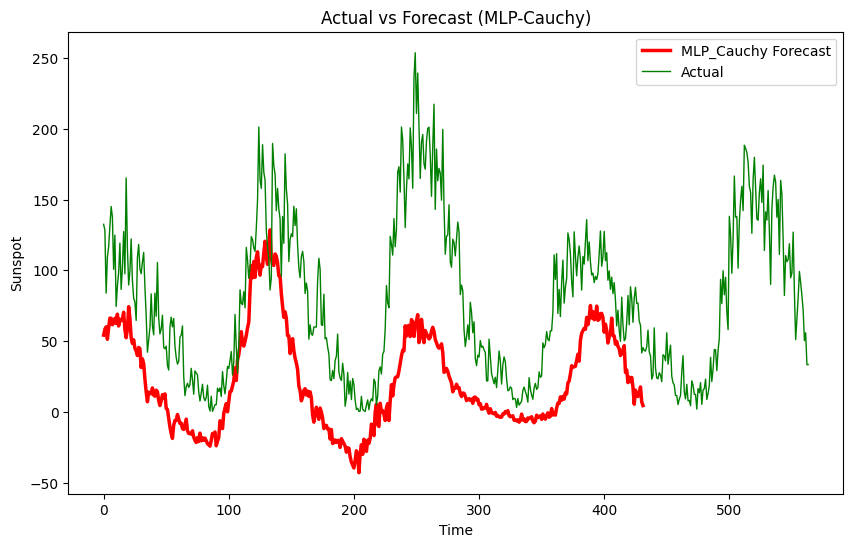


Evaluation Metrics
MSE   : 4376.781951731461
RMSE  : 66.15725169421309
NRMSE : 0.2608724435891683
MAE   : 57.914446981630235
SMAPE : 137.37367186844682
MASE  : 3.9108698235930484


In [5]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. CAUCHY LOSS
# =========================================================
def cauchy_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        loss_value = (
            (c ** 2) / 2.0
        ) * tf.math.log(
            1.0 + tf.square(error) / (c ** 2)
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (CAUCHY LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Cauchy loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=cauchy_loss(
            c=cfg['cauchy_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': cauchy_loss(
                cfg['cauchy_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Cauchy Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Cauchy)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (CAUCHY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Cauchy parameter
    'cauchy_c': 0.102,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\x_train_sunspot_full_5.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\y_train_sunspot_full_5.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_final_5.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_loss_history_5.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_5.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_5.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled_5.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled_5.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with Tukey's Biweight loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.7150e-04 - val_loss: 3.3421e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.2831e-04 - val_loss: 2.9963e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6956e-04 - val_loss: 2.8625e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2731e-04 - val_loss: 2.8236e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1557e-04 - val_loss: 2.7647e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1314e-04 - val_loss: 2.8462e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


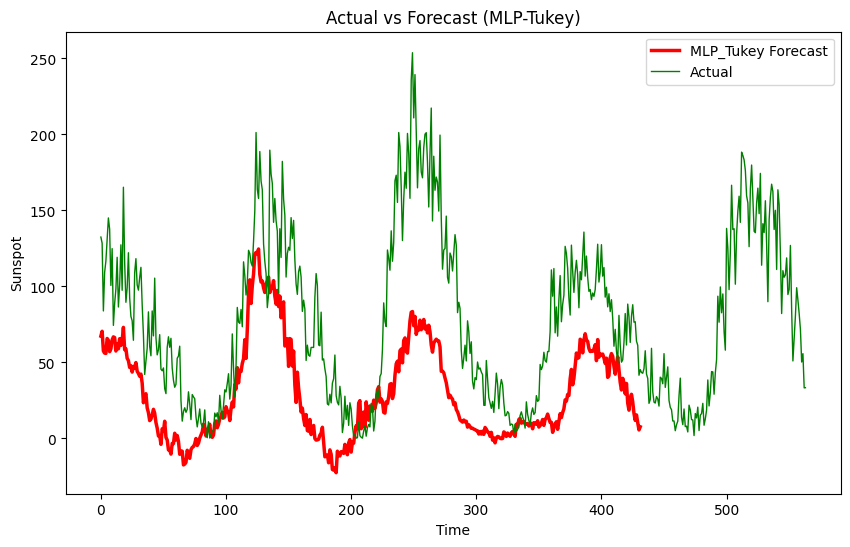


Evaluation Metrics
MSE   : 3873.8407248067124
RMSE  : 62.24018577098491
NRMSE : 0.24542660004331587
MAE   : 50.464942085277826
SMAPE : 107.96635593093743
MASE  : 3.4078166923235007


In [6]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. TUKEY'S BIWEIGHT LOSS
# =========================================================
def tukey_biweight_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        abs_error = tf.abs(error)

        # Region where |r| <= c
        inside = abs_error <= c

        # Tukey biweight expression
        scaled_error = error / c

        inside_loss = (
            (c ** 2) / 6.0
        ) * (
            1.0 -
            tf.pow(
                1.0 - tf.square(scaled_error),
                3
            )
        )

        # Constant loss for |r| > c
        outside_loss = (
            (c ** 2) / 6.0
        ) * tf.ones_like(error)

        loss_value = tf.where(
            inside,
            inside_loss,
            outside_loss
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (TUKEY'S BIWEIGHT LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Tukey's Biweight loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=tukey_biweight_loss(
            c=cfg['tukey_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': tukey_biweight_loss(
                cfg['tukey_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Tukey Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Tukey)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (TUKEY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Tukey's Biweight parameter
    'tukey_c': 0.100,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\x_train_sunspot_full_5.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\y_train_sunspot_full_5.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_final_5.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_loss_history_5.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_5.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_5.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled_5.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled_5.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with HawkEye loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.7338e-04 - val_loss: 7.2366e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6219e-04 - val_loss: 7.0511e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.9917e-04 - val_loss: 7.2727e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.0297e-04 - val_loss: 7.1709e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.1276e-04 - val_loss: 7.3527e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.8469e-04 - val_loss: 7.5954e-04
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


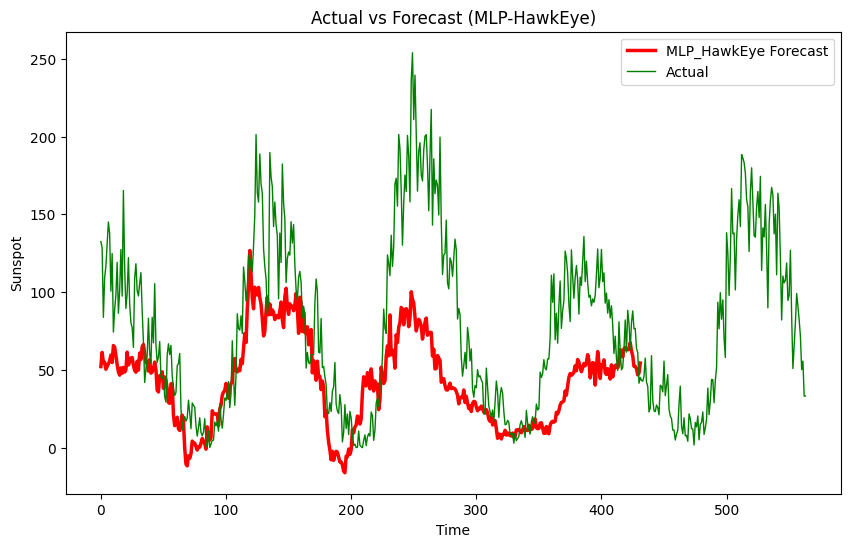


Evaluation Metrics
MSE   : 3185.462164480627
RMSE  : 56.43989869304008
NRMSE : 0.22255480557192459
MAE   : 41.78545885068792
SMAPE : 70.65549604831783
MASE  : 2.8217050943433595


In [7]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. HAWKEYE LOSS
# =========================================================
def hawkeye_loss(a=1.0, epsilon=0.02, lam=1.0):

    def loss(y_true, y_pred):

        # Residual
        r = y_true - y_pred

        # -------------------------------------------------
        # Left region: r <= -epsilon
        # -------------------------------------------------
        left_loss = lam * (
            1.0
            - (
                -a * (r + epsilon) + 1.0
            )
            * tf.exp(
                a * (r + epsilon)
            )
        )

        # -------------------------------------------------
        # Middle region: -epsilon < r < epsilon
        # -------------------------------------------------
        middle_loss = tf.zeros_like(r)

        # -------------------------------------------------
        # Right region: r >= epsilon
        # -------------------------------------------------
        right_loss = lam * (
            1.0
            - (
                a * (r - epsilon) + 1.0
            )
            * tf.exp(
                -a * (r - epsilon)
            )
        )

        # -------------------------------------------------
        # Piecewise HawkEye loss
        # -------------------------------------------------
        loss_value = tf.where(
            r <= -epsilon,
            left_loss,
            tf.where(
                r >= epsilon,
                right_loss,
                middle_loss
            )
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (HAWKEYE LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with HawkEye loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=hawkeye_loss(
            a=cfg['hawkeye_a'],
            epsilon=cfg['hawkeye_epsilon'],
            lam=cfg['hawkeye_lam']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': hawkeye_loss(
                a=cfg['hawkeye_a'],
                epsilon=cfg['hawkeye_epsilon'],
                lam=cfg['hawkeye_lam']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_HawkEye Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-HawkEye)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HAWKEYE NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # -----------------------------------------------------
    # HAWKEYE PARAMETERS
    # -----------------------------------------------------
    'hawkeye_a': 1.002,
    'hawkeye_epsilon': 0.029,
    'hawkeye_lam': 0.260,

    # -----------------------------------------------------
    # TRAIN / TEST DATA
    # -----------------------------------------------------
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\x_train_sunspot_full_5.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot_5\y_train_sunspot_full_5.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # -----------------------------------------------------
    # RAW TEST CSV
    # -----------------------------------------------------
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # -----------------------------------------------------
    # MODEL & LOGS
    # -----------------------------------------------------
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_final_5.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_loss_history_5.csv",

    # -----------------------------------------------------
    # FORECASTS
    # -----------------------------------------------------
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_5.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_5.csv",

    # -----------------------------------------------------
    # RESCALED FORECASTS
    # -----------------------------------------------------
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled_5.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled_5.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)